In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

transforms.ToTensor()

Converts images to tensor format

Pixel values scaled between 0–1

datasets.MNIST

Loads handwritten digit dataset (0–9)

DataLoader

Splits dataset into batches

batch_size=128 -> 128 images per batch

shuffle=True -> randomizes training data

Each image size = 28 × 28

In [ ]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder layers
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z

    def decode(self, z):
        h = self.relu(self.fc2(z))
        reconstruction = self.sigmoid(self.fc3(h))
        return reconstruction

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

Parameters: input_dim : Flattened image size = 28×28 = 784

hidden_dim : Size of hidden layer


latent_dim : Dimension of latent vector z

Encoder Layers
784 -> 400 -> μ and logσ²

fc1 -> First encoder layer

fc_mu -> Outputs mean

fc_logvar -> Outputs log variance

Decoder Layers:
z -> 400 -> 784
,Reconstructs the image.


Encoder compresses input image.

Steps:

Input image -> hidden layer

Hidden layer produces:

Mean (μ)

Log variance (logσ²)

Outputs represent latent space distribution parameters.

Steps:

Convert log variance -> standard deviation

Sample random noise

Generate latent vector z

Decoder reconstructs original image.

In [ ]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

Learning rate = 0.001

In [ ]:
def loss_function(recon_x, x, mu, logvar):

    # Reconstruction Loss
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    # KL Divergence Loss
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss, kl_loss

Reconstruction Loss

Measures how well decoder reconstructed the image.

Binary cross entropy is used.

KL Divergence

Ensures latent space follows Normal distribution.

Total Loss = Reconstruction Loss + KL Divergence

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.to(device)

        # Flatten images
        data = data.view(data.size(0), -1)

        optimizer.zero_grad()

        # Forward pass
        reconstruction, mu, logvar = model(data)

        # Loss calculation
        recon_loss, kl_loss = loss_function(reconstruction, data, mu, logvar)

        loss = recon_loss + kl_loss

        # Backpropagation
        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Reconstruction Loss: {total_recon:.2f}")
    print(f"KL Divergence Loss: {total_kl:.2f}")
    print("------------------------------------------------")

Epoch 1/10
Total Loss: 9859697.29
Reconstruction Loss: 8918907.97
KL Divergence Loss: 940789.32
------------------------------------------------
Epoch 2/10
Total Loss: 7314555.24
Reconstruction Loss: 5965305.41
KL Divergence Loss: 1349249.81
------------------------------------------------
Epoch 3/10
Total Loss: 6902009.67
Reconstruction Loss: 5464783.66
KL Divergence Loss: 1437226.00
------------------------------------------------
Epoch 4/10
Total Loss: 6714408.25
Reconstruction Loss: 5239897.06
KL Divergence Loss: 1474511.17
------------------------------------------------
Epoch 5/10
Total Loss: 6610235.57
Reconstruction Loss: 5116964.40
KL Divergence Loss: 1493271.17
------------------------------------------------
Epoch 6/10
Total Loss: 6533741.92
Reconstruction Loss: 5031989.60
KL Divergence Loss: 1501752.32
------------------------------------------------
Epoch 7/10
Total Loss: 6484367.82
Reconstruction Loss: 4975616.00
KL Divergence Loss: 1508751.82
----------------------------

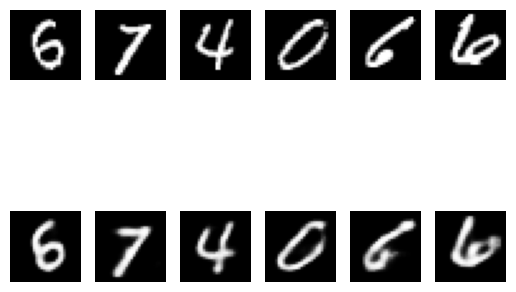

In [ ]:
model.eval()

with torch.no_grad():

    data, _ = next(iter(train_loader))
    data = data.to(device)

    data = data.view(data.size(0), -1)

    reconstruction, _, _ = model(data)

    original = data.view(-1, 28, 28).cpu()
    reconstructed = reconstruction.view(-1, 28, 28).cpu()

    fig, axes = plt.subplots(2,6)

    for i in range(6):

        axes[0,i].imshow(original[i], cmap='gray')
        axes[0,i].axis('off')

        axes[1,i].imshow(reconstructed[i], cmap='gray')
        axes[1,i].axis('off')

    plt.show()

Row 1 -> Original digits


Row 2 -> Reconstructed digits